In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import math

In [2]:
# HorizontalFlip 적용
#초기 코드에서 RandomCrop이 모델 성능에 부정적인 영향을 줌
define_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


# Load CIFAR-10 dataset
trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=define_transforms)
trainloader = DataLoader(trainset, batch_size=32, shuffle=True)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=define_transforms)

testloader = DataLoader(testset, batch_size=32, shuffle=False)

100%|██████████| 170M/170M [00:13<00:00, 12.6MB/s]


In [3]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.dropout = nn.Dropout(0.3) #dropout은 0.5이 가장 안정적이라고 알려져있지만 본 프로젝트중엔 예상과 다르게 0.3에서 가장 높은 정확도를 기록함
        self.relu = nn.LeakyReLU(0.1)  # ReLU → LeakyReLU로 변경후 정확도 7%p상승
        self.fc1 = nn.Linear(64 * 4 * 4, 256)  #  FC 확장 이후 정확도 상승
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        x = self.fc3(x)
        return x

In [4]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels,
                               kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels,
                               kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        out = self.relu(out)
        return out


In [5]:
class SimpleResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()


        # →기존 16채널 한계를 개선하기 위해 32채널부터 시작' 반영
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)       # 초기 층에서도 batch norm 적용- 학습 안정화
        self.relu = nn.ReLU(inplace=True)   # ReLU로 비선형성을 확보함

        # layer1: 32×32 해상도 유지, 채널 32 유지, residual block 2개 구성
        # stride=1 → 공간 크기 유지, 기본 특징 추출 단계
        self.layer1 = self._make_layer(32, 32, blocks=2, stride=1)

        # layer2: stride=2 → 해상도 32→16 감소, 채널은 32→64 확장
        #‘깊어질수록 더욱 추상적 특징 학습’ 반영
        self.layer2 = self._make_layer(32, 64, blocks=2, stride=2)

        # layer3: 다시 stride=2 → 해상도 16→8 감소, 채널 64→128 확장
        # deeper feature 학습을 위한 구조적 확장 단계
        self.layer3 = self._make_layer(64, 128, blocks=2, stride=2)

        # AdaptiveAvgPool → feature map을 1×1 크기로 축소
        # 모델 깊이와 상관없이 FC 입력 크기를 고정하는 역할
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # 최종 classifier: 128-dim → class logits
        self.fc = nn.Linear(128, num_classes)

    def _make_layer(self, in_channels, out_channels, blocks, stride):
        layers = []

        # 첫 블록:
        # stride가 1이 아니면 downsampling이 필요
        # → skip connection과 output 크기 맞추기 위해 projection shortcut(1x1 conv) 사용 가능
        layers.append(BasicBlock(in_channels, out_channels, stride))

        # 이후 블록들은 모두 stride=1
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_channels, out_channels, 1))

        return nn.Sequential(*layers)

    def forward(self, x):
        # 초기 conv + BN + ReLU
        x = self.relu(self.bn1(self.conv1(x)))

        # 각 residual layer 통과
        x = self.layer1(x)   # 32×32
        x = self.layer2(x)   # 16×16
        x = self.layer3(x)   # 8×8

        # Global average pooling
        x = self.avgpool(x)

        # Flatten하여 FC에 전달
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
#optimizer 변경 초기 SGD > Adam 학습률 0.01에서 0.001로 변경, L2정규화 Adam으로 변경후 심각한 underfitting 상태 관찰 최적화 문제 가능성도 있어서 학습률 조정
#underfitting원인 높은 학습률로인한 불안정한 weight업데이트로 판단

Using device: cuda


In [7]:
# 트레이닝함수
def train_model(model, trainloader, criterion, optimizer, num_epochs=10):
    train_losses = []
    train_accuracies = []
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        for i, (inputs, labels) in enumerate(trainloader, 0):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            if i % 100 == 99:
                print(f'[Epoch {epoch+1}, Batch {i+1}] loss: {running_loss/100:.3f}')
                running_loss = 0.0
        epoch_loss = running_loss / len(trainloader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        print(f'Epoch {epoch+1} accuracy: {epoch_acc:.2f}%')
    print('Training complete')
    return train_losses, train_accuracies


In [8]:
# 체킹함수
def test_model(model, testloader):
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f'Test Accuracy: {100 * correct / total:.2f}%')

In [9]:
def training_plot(train_losses, train_accuracies):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(epochs, train_losses, 'r-', label='Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, train_accuracies, 'b-', label='Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Training Accuracy')
    plt.legend()
    plt.show()


=== Train SimpleCNN ===
[Epoch 1, Batch 100] loss: 2.108
[Epoch 1, Batch 200] loss: 1.847
[Epoch 1, Batch 300] loss: 1.660
[Epoch 1, Batch 400] loss: 1.595
[Epoch 1, Batch 500] loss: 1.514
[Epoch 1, Batch 600] loss: 1.477
[Epoch 1, Batch 700] loss: 1.412
[Epoch 1, Batch 800] loss: 1.379
[Epoch 1, Batch 900] loss: 1.341
[Epoch 1, Batch 1000] loss: 1.314
[Epoch 1, Batch 1100] loss: 1.292
[Epoch 1, Batch 1200] loss: 1.240
[Epoch 1, Batch 1300] loss: 1.271
[Epoch 1, Batch 1400] loss: 1.233
[Epoch 1, Batch 1500] loss: 1.185
Epoch 1 accuracy: 47.08%
[Epoch 2, Batch 100] loss: 1.156
[Epoch 2, Batch 200] loss: 1.133
[Epoch 2, Batch 300] loss: 1.103
[Epoch 2, Batch 400] loss: 1.101
[Epoch 2, Batch 500] loss: 1.065
[Epoch 2, Batch 600] loss: 1.100
[Epoch 2, Batch 700] loss: 1.085
[Epoch 2, Batch 800] loss: 1.051
[Epoch 2, Batch 900] loss: 1.038
[Epoch 2, Batch 1000] loss: 1.050
[Epoch 2, Batch 1100] loss: 1.016
[Epoch 2, Batch 1200] loss: 1.018
[Epoch 2, Batch 1300] loss: 1.001
[Epoch 2, Batch 1

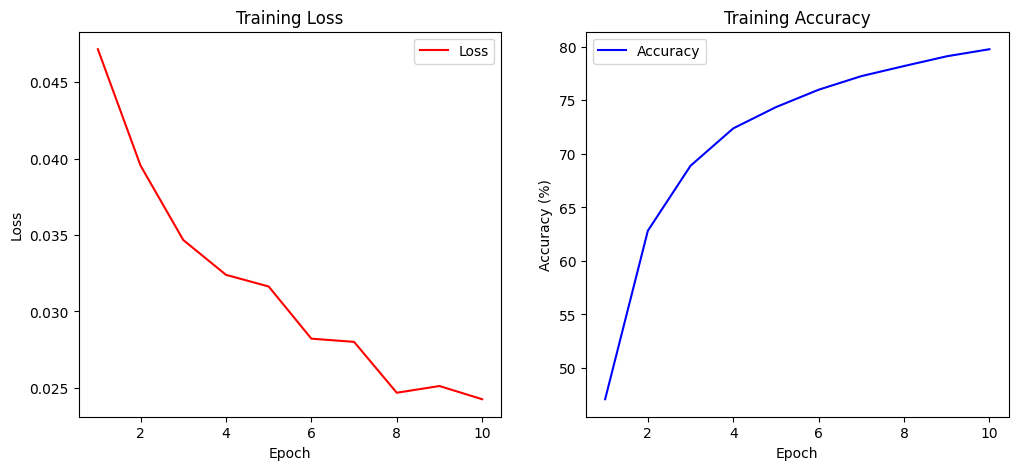


=== Train SimpleResNet ===
[Epoch 1, Batch 100] loss: 1.874
[Epoch 1, Batch 200] loss: 1.644
[Epoch 1, Batch 300] loss: 1.551
[Epoch 1, Batch 400] loss: 1.427
[Epoch 1, Batch 500] loss: 1.323
[Epoch 1, Batch 600] loss: 1.239
[Epoch 1, Batch 700] loss: 1.243
[Epoch 1, Batch 800] loss: 1.148
[Epoch 1, Batch 900] loss: 1.142
[Epoch 1, Batch 1000] loss: 1.074
[Epoch 1, Batch 1100] loss: 1.084
[Epoch 1, Batch 1200] loss: 1.012
[Epoch 1, Batch 1300] loss: 1.009
[Epoch 1, Batch 1400] loss: 1.007
[Epoch 1, Batch 1500] loss: 0.972
Epoch 1 accuracy: 55.25%
[Epoch 2, Batch 100] loss: 0.888
[Epoch 2, Batch 200] loss: 0.909
[Epoch 2, Batch 300] loss: 0.925
[Epoch 2, Batch 400] loss: 0.870
[Epoch 2, Batch 500] loss: 0.861
[Epoch 2, Batch 600] loss: 0.837
[Epoch 2, Batch 700] loss: 0.871
[Epoch 2, Batch 800] loss: 0.828
[Epoch 2, Batch 900] loss: 0.803
[Epoch 2, Batch 1000] loss: 0.791
[Epoch 2, Batch 1100] loss: 0.776
[Epoch 2, Batch 1200] loss: 0.730
[Epoch 2, Batch 1300] loss: 0.798
[Epoch 2, Bat

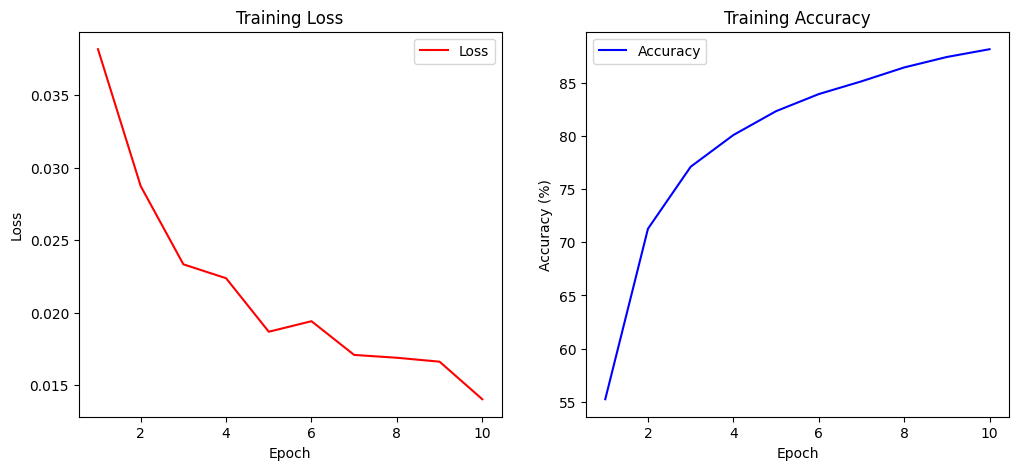

In [11]:
if __name__ == '__main__':
    # ----------------- SimpleCNN 학습 -----------------
    print('=== Train SimpleCNN ===')
    simple_model = SimpleCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer_simple = optim.Adam(simple_model.parameters(),
                                  lr=0.001, weight_decay=1e-4)

    simple_losses, simple_accs = train_model(
        simple_model, trainloader, criterion, optimizer_simple, num_epochs=10
    )
    print('[SimpleCNN] Test')
    test_model(simple_model, testloader)
    training_plot(simple_losses, simple_accs)

    # ----------------- SimpleResNet 학습 -----------------
    print('\n=== Train SimpleResNet ===')
    resnet_model = SimpleResNet(num_classes=10).to(device)
    optimizer_resnet = optim.Adam(resnet_model.parameters(),
                                  lr=0.001, weight_decay=1e-4)

    resnet_losses, resnet_accs = train_model(
        resnet_model, trainloader, criterion, optimizer_resnet, num_epochs=10
    )
    print('[SimpleResNet] Test')
    test_model(resnet_model, testloader)
    training_plot(resnet_losses, resnet_accs)


In [14]:
torch.save(model.state_dict(), "ResNetAIP.pth")


In [15]:
import os
print(os.listdir())

['.config', 'ResNetAIP.pth', 'data', 'sample_data']


In [16]:
from google.colab import files
files.download("ResNetAIP.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>